<a href="https://colab.research.google.com/github/darthnylus/frame-chime-clone/blob/main/LoanGuard_AI_Explainable_Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# LoanGuard AI  
## Explainable Loan Default Prediction

**Portfolio project:** Build an end-to-end machine-learning workflow that predicts loan-default risk and explains model decisions.

### What this notebook demonstrates

- Reproducible synthetic loan dataset generation
- Exploratory data analysis
- Feature engineering
- Leakage-safe preprocessing
- Logistic Regression and Random Forest modeling
- Imbalanced-class evaluation
- Probability calibration analysis
- Business-cost threshold optimization
- Global and local explainability
- Applicant-level scoring
- Model persistence

> **Important:** This notebook is an educational portfolio project. It must not be used to make real lending decisions or determine credit eligibility.



## 1. Environment setup

The notebook uses common data-science packages. SHAP is optional; if it is unavailable, the notebook falls back to standard feature importance.


In [1]:

# Uncomment only when packages are missing.
# %pip install -q pandas numpy matplotlib scikit-learn shap joblib

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.calibration import CalibrationDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Environment ready.")


Environment ready.



## 2. Generate a realistic synthetic loan dataset

A synthetic dataset makes the notebook immediately runnable and safe to publish. Replace this section later with a public dataset such as Home Credit, Lending Club, or Give Me Some Credit.

The target is:

- `default = 1`: borrower defaulted
- `default = 0`: borrower did not default


In [2]:

def generate_loan_data(n_rows: int = 12000, random_state: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)

    age = rng.integers(21, 70, n_rows)
    annual_income = np.exp(rng.normal(np.log(65000), 0.55, n_rows)).clip(18000, 300000)
    employment_years = np.minimum(rng.gamma(3.2, 2.0, n_rows), age - 18).clip(0, 40)
    loan_amount = np.exp(rng.normal(np.log(18000), 0.65, n_rows)).clip(1000, 120000)
    interest_rate = rng.normal(12.5, 4.0, n_rows).clip(3.0, 30.0)
    credit_score = rng.normal(680, 70, n_rows).clip(300, 850)
    existing_monthly_debt = np.exp(rng.normal(np.log(650), 0.75, n_rows)).clip(0, 6000)
    prior_late_payments = rng.poisson(0.65, n_rows).clip(0, 10)
    open_credit_lines = rng.poisson(7, n_rows).clip(1, 25)
    household_size = rng.integers(1, 7, n_rows)
    months_since_delinquency = rng.exponential(42, n_rows).clip(0, 180)

    home_ownership = rng.choice(
        ["RENT", "MORTGAGE", "OWN"],
        n_rows,
        p=[0.43, 0.46, 0.11],
    )
    loan_purpose = rng.choice(
        ["debt_consolidation", "home_improvement", "medical", "auto", "business", "other"],
        n_rows,
        p=[0.40, 0.15, 0.10, 0.12, 0.08, 0.15],
    )
    verification_status = rng.choice(
        ["verified", "source_verified", "not_verified"],
        n_rows,
        p=[0.38, 0.31, 0.31],
    )

    # Approximate monthly loan payment for a 36-month loan.
    monthly_rate = interest_rate / 100 / 12
    monthly_payment = (
        loan_amount * monthly_rate * (1 + monthly_rate) ** 36
        / ((1 + monthly_rate) ** 36 - 1)
    )

    monthly_income = annual_income / 12
    debt_to_income = (existing_monthly_debt + monthly_payment) / monthly_income
    loan_to_income = loan_amount / annual_income

    # Hidden risk process used only to construct the synthetic target.
    logit = (
        -3.35
        + 3.0 * debt_to_income
        + 1.4 * loan_to_income
        + 0.10 * (interest_rate - 10)
        - 0.008 * (credit_score - 650)
        - 0.035 * employment_years
        + 0.30 * prior_late_payments
        + 0.32 * (home_ownership == "RENT")
        + 0.42 * (loan_purpose == "business")
        + 0.20 * (verification_status == "not_verified")
        + rng.normal(0, 0.45, n_rows)
    )
    default_probability = 1 / (1 + np.exp(-logit))
    default = rng.binomial(1, default_probability)

    df = pd.DataFrame({
        "age": age,
        "annual_income": annual_income.round(2),
        "employment_years": employment_years.round(1),
        "loan_amount": loan_amount.round(2),
        "interest_rate": interest_rate.round(2),
        "credit_score": credit_score.round(0),
        "existing_monthly_debt": existing_monthly_debt.round(2),
        "prior_late_payments": prior_late_payments,
        "open_credit_lines": open_credit_lines,
        "household_size": household_size,
        "months_since_delinquency": months_since_delinquency.round(1),
        "home_ownership": home_ownership,
        "loan_purpose": loan_purpose,
        "verification_status": verification_status,
        "default": default,
    })

    # Add realistic missingness.
    for column, missing_rate in {
        "employment_years": 0.04,
        "credit_score": 0.02,
        "months_since_delinquency": 0.18,
        "verification_status": 0.01,
    }.items():
        mask = rng.random(n_rows) < missing_rate
        df.loc[mask, column] = np.nan

    return df


df = generate_loan_data()
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Default rate: {df['default'].mean():.2%}")
df.head()


Rows: 12,000
Columns: 15
Default rate: 22.85%


,age,annual_income,employment_years,loan_amount,interest_rate,credit_score,existing_monthly_debt,prior_late_payments,open_credit_lines,household_size,months_since_delinquency,home_ownership,loan_purpose,verification_status,default
0,25,"36,746.410",7.000,"3,502.490",13.850,816.000,933.840,0,3,4,NaN,MORTGAGE,other,verified,0
1,58,"84,761.110",2.300,"13,049.410",17.340,NaN,"1,312.490",1,7,5,116.500,MORTGAGE,debt_consolidation,source_verified,0
2,53,"46,536.930",9.700,"6,791.240",12.700,665.000,674.180,0,9,2,12.500,OWN,debt_consolidation,verified,0
3,42,"26,243.040",3.000,"13,992.290",11.560,720.000,541.680,0,8,5,4.800,MORTGAGE,debt_consolidation,not_verified,0
4,42,"55,494.180",6.100,"13,107.670",15.990,591.000,239.920,3,4,4,49.500,RENT,debt_consolidation,source_verified,1



## 3. Data-quality review


In [3]:

quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_values": df.nunique(),
}).sort_values("missing_pct", ascending=False)

quality_summary


,dtype,missing_count,missing_pct,unique_values
months_since_delinquency,float64,2125,17.710,1430
employment_years,float64,438,3.650,210
credit_score,float64,233,1.940,385
verification_status,object,132,1.100,3
loan_amount,float64,0,0.000,11956
annual_income,float64,0,0.000,11837
age,int64,0,0.000,49
existing_monthly_debt,float64,0,0.000,11521
interest_rate,float64,0,0.000,1848
open_credit_lines,int64,0,0.000,19


In [4]:

print(f"Duplicate rows: {df.duplicated().sum():,}")
df.describe(include="all").T


Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,"12,000.000",NaN,NaN,NaN,44.876,14.065,21.000,33.000,45.000,57.000,69.000
annual_income,"12,000.000",NaN,NaN,NaN,"75,721.035","44,371.162","18,000.000","45,141.542","64,375.610","94,087.815","300,000.000"
employment_years,"11,562.000",NaN,NaN,NaN,6.158,3.414,0.200,3.600,5.600,8.000,29.800
loan_amount,"12,000.000",NaN,NaN,NaN,"21,926.735","15,446.349","1,420.430","11,647.110","17,745.140","27,444.425","120,000.000"
interest_rate,"12,000.000",NaN,NaN,NaN,12.481,3.988,3.000,9.730,12.470,15.200,29.240
credit_score,"11,767.000",NaN,NaN,NaN,680.050,69.760,408.000,633.000,679.000,728.000,850.000
existing_monthly_debt,"12,000.000",NaN,NaN,NaN,856.612,735.593,46.580,386.665,641.415,"1,071.070","6,000.000"
prior_late_payments,"12,000.000",NaN,NaN,NaN,0.650,0.817,0.000,0.000,0.000,1.000,6.000
open_credit_lines,"12,000.000",NaN,NaN,NaN,6.984,2.642,1.000,5.000,7.000,9.000,19.000
household_size,"12,000.000",NaN,NaN,NaN,3.507,1.717,1.000,2.000,4.000,5.000,6.000



## 4. Exploratory data analysis


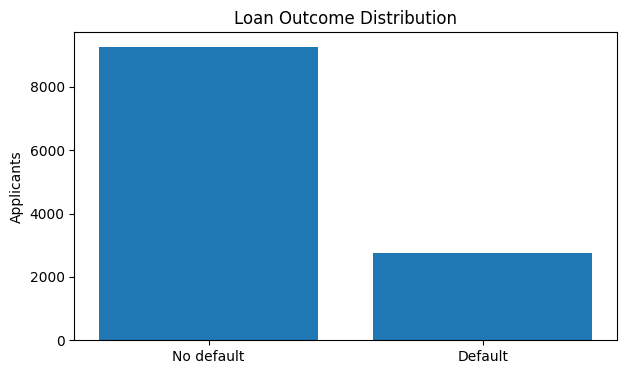

In [5]:

default_counts = df["default"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(["No default", "Default"], default_counts.values)
plt.title("Loan Outcome Distribution")
plt.ylabel("Applicants")
plt.show()


In [6]:

numeric_eda_columns = [
    "annual_income",
    "loan_amount",
    "interest_rate",
    "credit_score",
    "existing_monthly_debt",
    "prior_late_payments",
]

grouped_means = df.groupby("default")[numeric_eda_columns].mean().T
grouped_means.columns = ["No default", "Default"]
grouped_means


,No default,Default
annual_income,"81,232.004","57,113.978"
loan_amount,"19,913.625","28,723.736"
interest_rate,12.179,13.502
credit_score,686.584,657.907
existing_monthly_debt,791.260,"1,077.262"
prior_late_payments,0.615,0.770


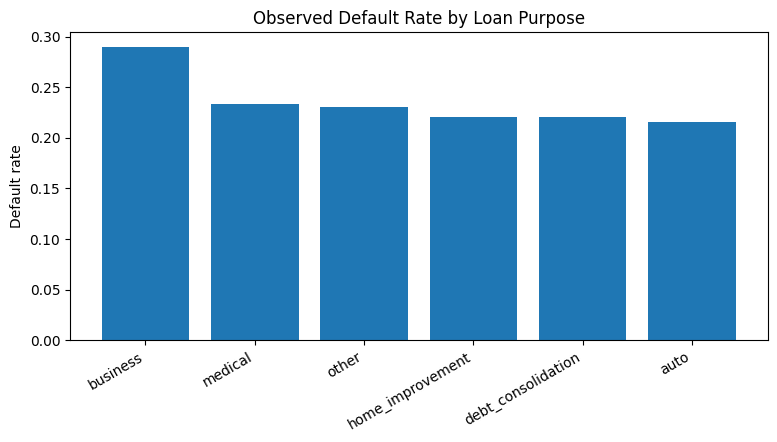

,mean,count
loan_purpose,,
business,0.290,959
medical,0.234,1160
other,0.231,1813
home_improvement,0.221,1791
debt_consolidation,0.221,4818
auto,0.216,1459


In [7]:

purpose_default_rate = (
    df.groupby("loan_purpose")["default"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

plt.figure(figsize=(9, 4))
plt.bar(purpose_default_rate.index, purpose_default_rate["mean"])
plt.title("Observed Default Rate by Loan Purpose")
plt.ylabel("Default rate")
plt.xticks(rotation=30, ha="right")
plt.show()

purpose_default_rate



## 5. Feature engineering

These features express the applicant's financial obligations relative to income and available resources.


In [8]:

def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()

    result["monthly_income"] = result["annual_income"] / 12
    result["loan_to_income_ratio"] = (
        result["loan_amount"] / result["annual_income"].replace(0, np.nan)
    )
    result["debt_to_monthly_income_ratio"] = (
        result["existing_monthly_debt"] / result["monthly_income"].replace(0, np.nan)
    )
    result["income_per_household_member"] = (
        result["annual_income"] / result["household_size"].replace(0, np.nan)
    )
    result["employment_to_age_ratio"] = (
        result["employment_years"] / result["age"].replace(0, np.nan)
    )
    result["credit_lines_per_year_employed"] = (
        result["open_credit_lines"] / (result["employment_years"].fillna(0) + 1)
    )

    return result


model_df = engineer_features(df)
model_df.head()


,age,annual_income,employment_years,loan_amount,interest_rate,credit_score,existing_monthly_debt,prior_late_payments,open_credit_lines,household_size,months_since_delinquency,home_ownership,loan_purpose,verification_status,default,monthly_income,loan_to_income_ratio,debt_to_monthly_income_ratio,income_per_household_member,employment_to_age_ratio,credit_lines_per_year_employed
0,25,"36,746.410",7.000,"3,502.490",13.850,816.000,933.840,0,3,4,NaN,MORTGAGE,other,verified,0,"3,062.201",0.095,0.305,"9,186.603",0.280,0.375
1,58,"84,761.110",2.300,"13,049.410",17.340,NaN,"1,312.490",1,7,5,116.500,MORTGAGE,debt_consolidation,source_verified,0,"7,063.426",0.154,0.186,"16,952.222",0.040,2.121
2,53,"46,536.930",9.700,"6,791.240",12.700,665.000,674.180,0,9,2,12.500,OWN,debt_consolidation,verified,0,"3,878.077",0.146,0.174,"23,268.465",0.183,0.841
3,42,"26,243.040",3.000,"13,992.290",11.560,720.000,541.680,0,8,5,4.800,MORTGAGE,debt_consolidation,not_verified,0,"2,186.920",0.533,0.248,"5,248.608",0.071,2.000
4,42,"55,494.180",6.100,"13,107.670",15.990,591.000,239.920,3,4,4,49.500,RENT,debt_consolidation,source_verified,1,"4,624.515",0.236,0.052,"13,873.545",0.145,0.563



## 6. Train, validation, and test split

A separate test set is held back until the final evaluation.


In [9]:

TARGET = "default"

X = model_df.drop(columns=TARGET)
y = model_df[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

print(f"Training rows:   {len(X_train):,}")
print(f"Validation rows: {len(X_valid):,}")
print(f"Test rows:       {len(X_test):,}")
print(f"Training default rate: {y_train.mean():.2%}")


Training rows:   7,200
Validation rows: 2,400
Test rows:       2,400
Training default rate: 22.86%



## 7. Leakage-safe preprocessing pipelines


In [10]:

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_transformer_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor_scaled = ColumnTransformer([
    ("numeric", numeric_transformer_scaled, numeric_features),
    ("categorical", categorical_transformer, categorical_features),
])

preprocessor_unscaled = ColumnTransformer([
    ("numeric", numeric_transformer_unscaled, numeric_features),
    ("categorical", categorical_transformer, categorical_features),
])

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")


Numeric features: 17
Categorical features: 3



## 8. Train baseline and nonlinear models


In [11]:

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

forest_pipeline = Pipeline([
    ("preprocessor", preprocessor_unscaled),
    ("model", RandomForestClassifier(
        n_estimators=350,
        max_depth=10,
        min_samples_leaf=8,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": forest_pipeline,
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Random Forest



## 9. Evaluation helper

Credit-risk models should not be judged by accuracy alone. This notebook emphasizes ROC-AUC, PR-AUC, recall, precision, balanced accuracy, and probability calibration.


In [12]:

def evaluate_classifier(model, X_eval, y_eval, threshold=0.50) -> dict:
    probabilities = model.predict_proba(X_eval)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    return {
        "roc_auc": roc_auc_score(y_eval, probabilities),
        "pr_auc": average_precision_score(y_eval, probabilities),
        "precision": precision_score(y_eval, predictions, zero_division=0),
        "recall": recall_score(y_eval, predictions, zero_division=0),
        "f1": f1_score(y_eval, predictions, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_eval, predictions),
        "accuracy": accuracy_score(y_eval, predictions),
        "brier_score": brier_score_loss(y_eval, probabilities),
    }


validation_results = pd.DataFrame({
    name: evaluate_classifier(model, X_valid, y_valid)
    for name, model in models.items()
}).T.sort_values("pr_auc", ascending=False)

validation_results


,roc_auc,pr_auc,precision,recall,f1,balanced_accuracy,accuracy,brier_score
Logistic Regression,0.817,0.645,0.462,0.704,0.558,0.731,0.745,0.172
Random Forest,0.808,0.621,0.550,0.580,0.565,0.720,0.796,0.155


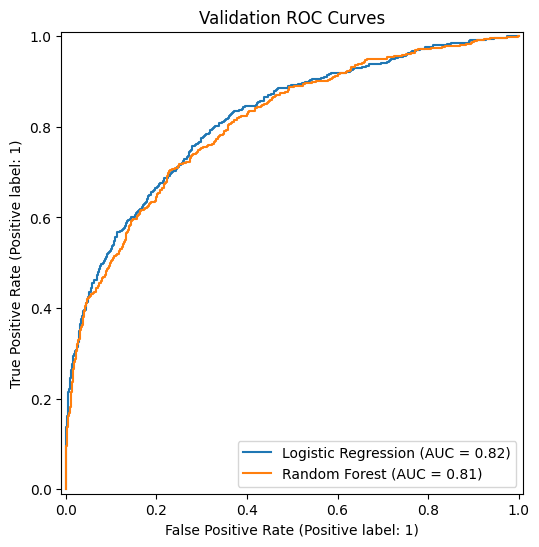

In [13]:

plt.figure(figsize=(8, 6))
ax = plt.gca()
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_valid, y_valid, name=name, ax=ax)
plt.title("Validation ROC Curves")
plt.show()


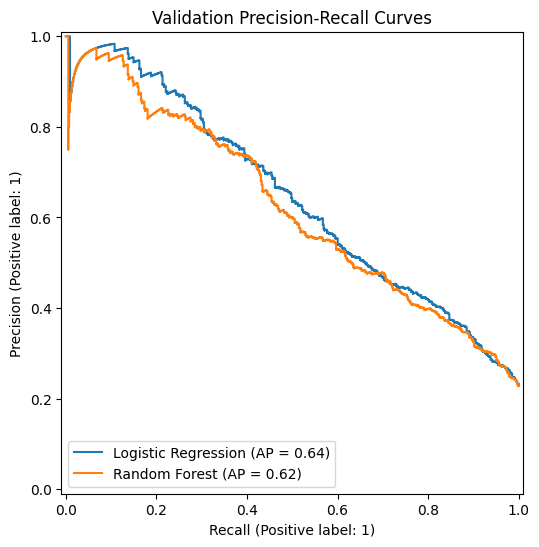

In [14]:

plt.figure(figsize=(8, 6))
ax = plt.gca()
for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(model, X_valid, y_valid, name=name, ax=ax)
plt.title("Validation Precision-Recall Curves")
plt.show()



## 10. Optional Random Forest hyperparameter tuning

Randomized search provides a practical compromise between coverage and runtime.


In [15]:

RUN_TUNING = False

if RUN_TUNING:
    parameter_distributions = {
        "model__n_estimators": [250, 400, 600],
        "model__max_depth": [6, 8, 10, 14, None],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [2, 5, 8, 12],
        "model__max_features": ["sqrt", "log2", 0.5],
    }

    search = RandomizedSearchCV(
        estimator=clone(forest_pipeline),
        param_distributions=parameter_distributions,
        n_iter=18,
        scoring="average_precision",
        cv=3,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
    )
    search.fit(X_train, y_train)
    forest_pipeline = search.best_estimator_
    models["Random Forest"] = forest_pipeline

    print("Best parameters:")
    print(search.best_params_)
    print(f"Best cross-validation PR-AUC: {search.best_score_:.4f}")
else:
    print("Tuning skipped. Set RUN_TUNING = True to run it.")


Tuning skipped. Set RUN_TUNING = True to run it.



## 11. Business-cost threshold optimization

A threshold of 0.50 is rarely optimal for an imbalanced business problem.

The demonstration assumptions below are configurable:

- Missed default: **$15,000**
- Incorrect high-risk flag: **$1,500**
- Manual review for any flagged applicant: **$100**


In [16]:

FALSE_NEGATIVE_COST = 15000
FALSE_POSITIVE_COST = 1500
REVIEW_COST = 100

best_model_name = validation_results.index[0]
best_model = models[best_model_name]
valid_probabilities = best_model.predict_proba(X_valid)[:, 1]

threshold_rows = []

for threshold in np.linspace(0.05, 0.80, 151):
    predictions = (valid_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_valid, predictions).ravel()

    total_cost = (
        fn * FALSE_NEGATIVE_COST
        + fp * FALSE_POSITIVE_COST
        + (tp + fp) * REVIEW_COST
    )

    threshold_rows.append({
        "threshold": threshold,
        "total_cost": total_cost,
        "precision": precision_score(y_valid, predictions, zero_division=0),
        "recall": recall_score(y_valid, predictions, zero_division=0),
        "false_negatives": fn,
        "false_positives": fp,
        "flagged_applicants": int(tp + fp),
    })

threshold_results = pd.DataFrame(threshold_rows)
optimal_row = threshold_results.loc[threshold_results["total_cost"].idxmin()]
optimal_threshold = float(optimal_row["threshold"])

print(f"Selected model: {best_model_name}")
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"Estimated validation cost: ${optimal_row['total_cost']:,.0f}")
optimal_row.to_frame("value")


Selected model: Logistic Regression
Optimal threshold: 0.325
Estimated validation cost: $2,387,100


,value
threshold,0.325
total_cost,"2,387,100.000"
precision,0.358
recall,0.885
false_negatives,63.000
false_positives,871.000
flagged_applicants,"1,356.000"


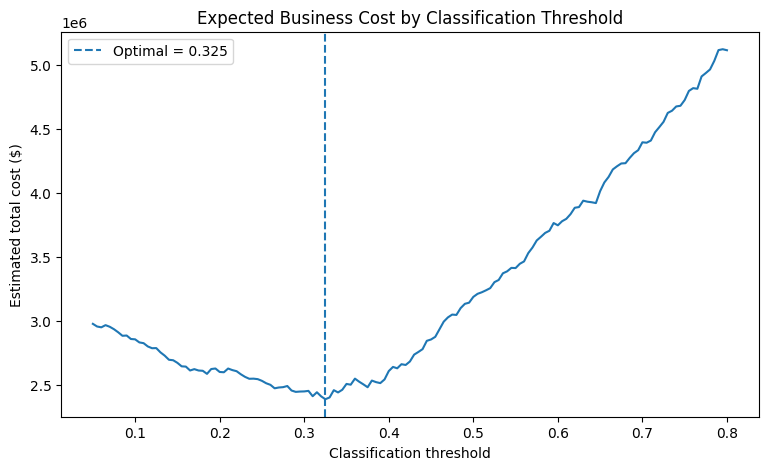

In [17]:

plt.figure(figsize=(9, 5))
plt.plot(threshold_results["threshold"], threshold_results["total_cost"])
plt.axvline(optimal_threshold, linestyle="--", label=f"Optimal = {optimal_threshold:.3f}")
plt.title("Expected Business Cost by Classification Threshold")
plt.xlabel("Classification threshold")
plt.ylabel("Estimated total cost ($)")
plt.legend()
plt.show()



## 12. Probability calibration


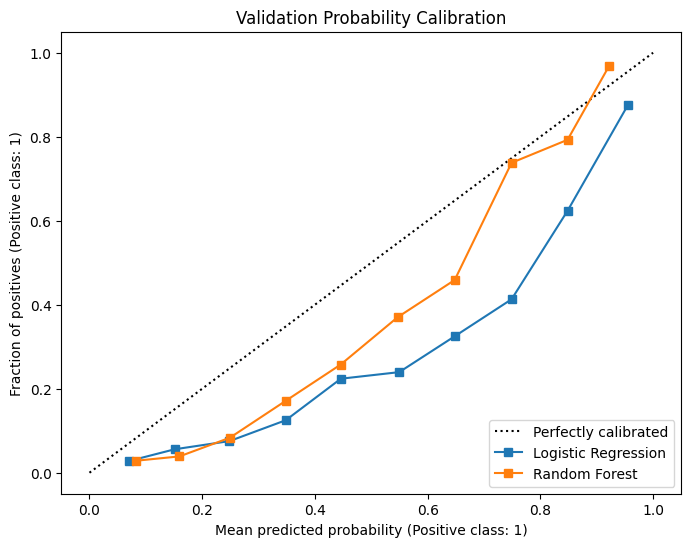

In [18]:

plt.figure(figsize=(8, 6))
ax = plt.gca()

for name, model in models.items():
    CalibrationDisplay.from_estimator(
        model,
        X_valid,
        y_valid,
        n_bins=10,
        name=name,
        ax=ax,
    )

plt.title("Validation Probability Calibration")
plt.show()



## 13. Final test-set evaluation

The test set is evaluated only after the model and threshold are selected.


In [19]:

# Refit the selected pipeline using all non-test data.
final_model = clone(best_model)
final_model.fit(X_train_full, y_train_full)

test_probabilities = final_model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= optimal_threshold).astype(int)

test_metrics = evaluate_classifier(
    final_model,
    X_test,
    y_test,
    threshold=optimal_threshold,
)

pd.Series(test_metrics, name="Test performance").to_frame()


,Test performance
roc_auc,0.809
pr_auc,0.623
precision,0.349
recall,0.858
f1,0.496
balanced_accuracy,0.692
accuracy,0.603
brier_score,0.171


              precision    recall  f1-score   support

  No default       0.93      0.53      0.67      1852
     Default       0.35      0.86      0.50       548

    accuracy                           0.60      2400
   macro avg       0.64      0.69      0.58      2400
weighted avg       0.79      0.60      0.63      2400



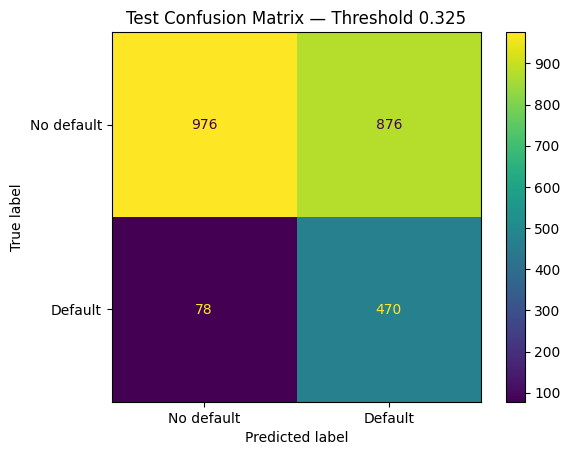

In [20]:

print(classification_report(
    y_test,
    test_predictions,
    target_names=["No default", "Default"],
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["No default", "Default"],
)
plt.title(f"Test Confusion Matrix — Threshold {optimal_threshold:.3f}")
plt.show()



## 14. Global model explainability

Permutation importance measures how much model performance decreases when each original feature is randomly shuffled.


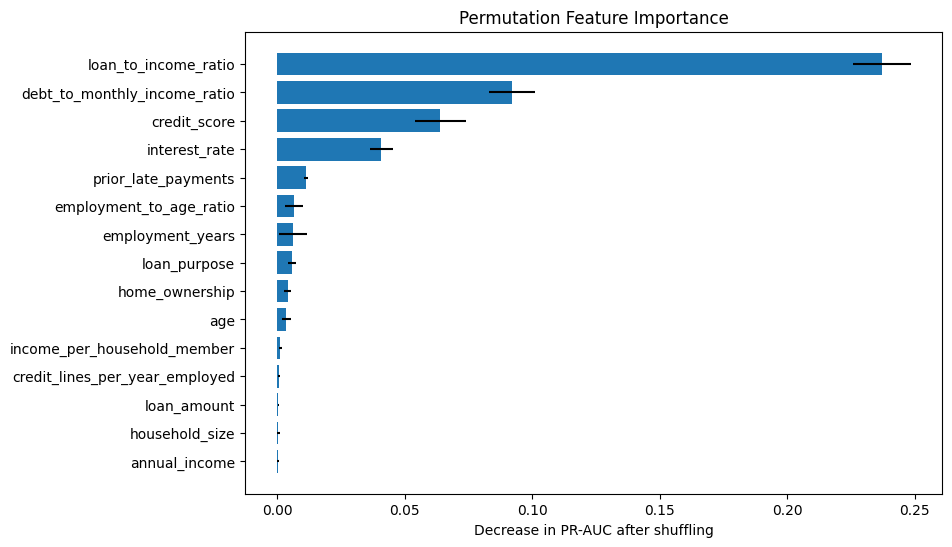

,feature,importance_mean,importance_std
15,loan_to_income_ratio,0.237,0.011
16,debt_to_monthly_income_ratio,0.092,0.009
5,credit_score,0.064,0.010
4,interest_rate,0.041,0.005
7,prior_late_payments,0.011,0.001
18,employment_to_age_ratio,0.007,0.003
2,employment_years,0.006,0.006
12,loan_purpose,0.006,0.002
11,home_ownership,0.004,0.001
0,age,0.003,0.002


In [21]:

permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance_mean"][::-1],
    xerr=importance_df["importance_std"][::-1],
)
plt.title("Permutation Feature Importance")
plt.xlabel("Decrease in PR-AUC after shuffling")
plt.show()

importance_df



## 15. SHAP explainability

This section uses SHAP when installed. It explains the transformed feature space used by the Random Forest.


In [22]:

try:
    import shap

    if best_model_name != "Random Forest":
        print("SHAP tree explanation is configured for the Random Forest model.")
    else:
        fitted_preprocessor = final_model.named_steps["preprocessor"]
        fitted_estimator = final_model.named_steps["model"]

        sample = X_test.sample(min(500, len(X_test)), random_state=RANDOM_STATE)
        transformed_sample = fitted_preprocessor.transform(sample)
        transformed_names = fitted_preprocessor.get_feature_names_out()

        explainer = shap.TreeExplainer(fitted_estimator)
        shap_values = explainer.shap_values(transformed_sample)

        # SHAP versions return either a list or a 3D array for binary classifiers.
        if isinstance(shap_values, list):
            positive_class_values = shap_values[1]
        elif np.asarray(shap_values).ndim == 3:
            positive_class_values = np.asarray(shap_values)[:, :, 1]
        else:
            positive_class_values = np.asarray(shap_values)

        shap.summary_plot(
            positive_class_values,
            transformed_sample,
            feature_names=transformed_names,
            show=False,
            max_display=15,
        )
        plt.title("SHAP Global Feature Impact")
        plt.tight_layout()
        plt.show()

except ImportError:
    print("SHAP is not installed. Run `%pip install shap` and rerun this cell.")
except Exception as exc:
    print(f"SHAP could not be rendered in this environment: {exc}")


SHAP tree explanation is configured for the Random Forest model.



## 16. Partial dependence

Partial dependence shows the average predicted relationship between selected features and default risk.


In [ ]:

features_to_plot = [
    feature for feature in
    ["credit_score", "interest_rate", "loan_to_income_ratio", "prior_late_payments"]
    if feature in X_test.columns
]

for feature in features_to_plot:
    fig, ax = plt.subplots(figsize=(7, 4))
    PartialDependenceDisplay.from_estimator(
        final_model,
        X_test.sample(min(1500, len(X_test)), random_state=RANDOM_STATE),
        [feature],
        ax=ax,
    )
    plt.title(f"Partial Dependence: {feature}")
    plt.show()



## 17. Score and explain one applicant

The explanation below compares the applicant's numeric values with the training population. It is intentionally plain-language and does not claim causality.


In [23]:

def assign_risk_tier(probability: float) -> str:
    if probability < 0.10:
        return "Low"
    if probability < 0.25:
        return "Moderate"
    if probability < 0.50:
        return "High"
    return "Very High"


def applicant_summary(
    model,
    applicant: pd.DataFrame,
    reference_data: pd.DataFrame,
    threshold: float,
) -> dict:
    probability = float(model.predict_proba(applicant)[:, 1][0])

    numeric_comparisons = []
    for column in [
        "credit_score",
        "interest_rate",
        "loan_to_income_ratio",
        "debt_to_monthly_income_ratio",
        "prior_late_payments",
        "employment_years",
    ]:
        if column not in applicant.columns:
            continue

        value = applicant.iloc[0][column]
        median = reference_data[column].median()

        if pd.isna(value):
            continue

        if column in {"credit_score", "employment_years"}:
            risk_direction = "increases risk" if value < median else "reduces risk"
            difference = value - median
        else:
            risk_direction = "increases risk" if value > median else "reduces risk"
            difference = value - median

        numeric_comparisons.append({
            "feature": column,
            "applicant_value": value,
            "training_median": median,
            "difference": difference,
            "direction": risk_direction,
            "absolute_standardized_difference": abs(
                difference / (reference_data[column].std() + 1e-9)
            ),
        })

    drivers = (
        pd.DataFrame(numeric_comparisons)
        .sort_values("absolute_standardized_difference", ascending=False)
        .head(5)
    )

    return {
        "default_probability": probability,
        "risk_tier": assign_risk_tier(probability),
        "flag_for_review": probability >= threshold,
        "drivers": drivers,
    }


applicant = X_test.iloc[[0]].copy()
result = applicant_summary(
    final_model,
    applicant,
    X_train_full,
    optimal_threshold,
)

print(f"Predicted default probability: {result['default_probability']:.1%}")
print(f"Risk tier: {result['risk_tier']}")
print(f"Flag for manual review: {result['flag_for_review']}")
result["drivers"]


Predicted default probability: 26.8%
Risk tier: High
Flag for manual review: False


,feature,applicant_value,training_median,difference,direction,absolute_standardized_difference
4,prior_late_payments,1.000,0.000,1.000,increases risk,1.218
3,debt_to_monthly_income_ratio,0.332,0.118,0.214,increases risk,1.040
5,employment_years,8.500,5.600,2.900,reduces risk,0.843
1,interest_rate,9.560,12.470,-2.910,reduces risk,0.734
2,loan_to_income_ratio,0.120,0.277,-0.157,reduces risk,0.413



## 18. Simple counterfactual scenario

This demonstration changes only potentially actionable variables. It does not recommend changing immutable personal characteristics.

A production counterfactual system should enforce stronger feasibility, legal, causal, and data-quality constraints.


In [24]:

def create_counterfactual(applicant: pd.DataFrame) -> pd.DataFrame:
    scenario = applicant.copy()

    # Demonstration adjustments only.
    scenario["loan_amount"] = scenario["loan_amount"] * 0.80
    scenario["existing_monthly_debt"] = scenario["existing_monthly_debt"] * 0.75
    scenario["interest_rate"] = np.maximum(scenario["interest_rate"] - 2.0, 3.0)

    # Recalculate engineered variables.
    scenario["monthly_income"] = scenario["annual_income"] / 12
    scenario["loan_to_income_ratio"] = (
        scenario["loan_amount"] / scenario["annual_income"].replace(0, np.nan)
    )
    scenario["debt_to_monthly_income_ratio"] = (
        scenario["existing_monthly_debt"]
        / scenario["monthly_income"].replace(0, np.nan)
    )
    scenario["income_per_household_member"] = (
        scenario["annual_income"]
        / scenario["household_size"].replace(0, np.nan)
    )
    scenario["employment_to_age_ratio"] = (
        scenario["employment_years"]
        / scenario["age"].replace(0, np.nan)
    )
    scenario["credit_lines_per_year_employed"] = (
        scenario["open_credit_lines"]
        / (scenario["employment_years"].fillna(0) + 1)
    )

    return scenario


counterfactual = create_counterfactual(applicant)

original_probability = float(final_model.predict_proba(applicant)[:, 1][0])
counterfactual_probability = float(final_model.predict_proba(counterfactual)[:, 1][0])

comparison = pd.DataFrame({
    "scenario": ["Original applicant", "Counterfactual scenario"],
    "loan_amount": [
        applicant.iloc[0]["loan_amount"],
        counterfactual.iloc[0]["loan_amount"],
    ],
    "existing_monthly_debt": [
        applicant.iloc[0]["existing_monthly_debt"],
        counterfactual.iloc[0]["existing_monthly_debt"],
    ],
    "interest_rate": [
        applicant.iloc[0]["interest_rate"],
        counterfactual.iloc[0]["interest_rate"],
    ],
    "predicted_default_probability": [
        original_probability,
        counterfactual_probability,
    ],
})

comparison


,scenario,loan_amount,existing_monthly_debt,interest_rate,predicted_default_probability
0,Original applicant,"17,603.010","4,077.510",9.560,0.268
1,Counterfactual scenario,"14,082.408","3,058.133",7.560,0.170



## 19. Batch scoring function


In [25]:

def score_applicants(
    model,
    raw_applicants: pd.DataFrame,
    threshold: float,
) -> pd.DataFrame:
    prepared = engineer_features(raw_applicants)
    probabilities = model.predict_proba(prepared)[:, 1]

    scored = raw_applicants.copy()
    scored["predicted_default_probability"] = probabilities
    scored["risk_tier"] = [assign_risk_tier(p) for p in probabilities]
    scored["manual_review_flag"] = probabilities >= threshold

    return scored.sort_values(
        "predicted_default_probability",
        ascending=False,
    )


sample_batch = df.drop(columns=TARGET).sample(10, random_state=7)
scored_batch = score_applicants(
    final_model,
    sample_batch,
    optimal_threshold,
)

scored_batch[[
    "annual_income",
    "loan_amount",
    "credit_score",
    "interest_rate",
    "predicted_default_probability",
    "risk_tier",
    "manual_review_flag",
]]


,annual_income,loan_amount,credit_score,interest_rate,predicted_default_probability,risk_tier,manual_review_flag
1857,"30,160.490","21,367.250",543.000,6.870,0.647,Very High,True
2105,"91,675.190","18,751.400",693.000,16.720,0.492,High,True
7200,"58,031.030","12,054.360",697.000,12.090,0.367,High,True
5988,"125,717.020","25,676.360",683.000,16.190,0.336,High,True
7451,"62,312.080","7,263.650",783.000,17.750,0.299,High,False
3433,"78,777.490","16,118.520",756.000,17.110,0.238,Moderate,False
247,"43,719.890","17,401.170",718.000,10.140,0.224,Moderate,False
8370,"100,227.330","24,728.010",671.000,11.500,0.188,Moderate,False
4036,"150,578.730","27,490.360",695.000,10.980,0.144,Moderate,False
9063,"153,044.240","11,738.150",764.000,7.650,0.049,Low,False



## 20. Save model artifacts

The model pipeline contains both preprocessing and prediction logic.


In [26]:

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(final_model, ARTIFACT_DIR / "loan_default_pipeline.joblib")

metadata = {
    "model_name": best_model_name,
    "classification_threshold": optimal_threshold,
    "target": TARGET,
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "feature_columns": X.columns.tolist(),
    "educational_use_only": True,
}

with open(ARTIFACT_DIR / "model_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print(f"Saved model to: {ARTIFACT_DIR / 'loan_default_pipeline.joblib'}")
print(f"Saved metadata to: {ARTIFACT_DIR / 'model_metadata.json'}")


Saved model to: artifacts/loan_default_pipeline.joblib
Saved metadata to: artifacts/model_metadata.json



## 21. Model card

### Intended use
- Educational portfolio demonstration
- Exploration of explainable binary classification
- Illustration of risk scoring, threshold selection, and model monitoring concepts

### Prohibited use
- Real lending approval or denial
- Automated adverse-action decisions
- Use without legal, compliance, fairness, privacy, and security review

### Important limitations
- The data is synthetic.
- The cost assumptions are hypothetical.
- Statistical associations are not causal explanations.
- The model may reproduce bias contained in its training data.
- A real system would require rigorous validation, governance, documentation, monitoring, and human oversight.

### Suggested portfolio extensions
1. Replace synthetic data with a documented public dataset.
2. Add XGBoost or LightGBM.
3. Add Optuna hyperparameter optimization.
4. Add Fairlearn subgroup metrics.
5. Add Evidently drift reports.
6. Build a Streamlit application.
7. Track experiments with MLflow.
8. Add unit tests and GitHub Actions.



## 22. Portfolio-ready conclusion

This project demonstrates the complete lifecycle of an explainable machine-learning classification system:

- business framing
- data validation
- exploratory analysis
- feature engineering
- reproducible preprocessing
- imbalanced-class modeling
- model comparison
- business-cost optimization
- probability calibration
- global and local explainability
- batch scoring
- artifact persistence
- responsible-AI documentation

A strong portfolio presentation should emphasize not only predictive performance, but also transparency, limitations, business impact, and responsible use.
